In [70]:
!apt-get update -qq
!apt-get install -y ncbi-blast+ > /dev/null

!blastp -version
!makeblastdb -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
blastp: 2.12.0+
 Package: blast 2.12.0, build Mar  8 2022 16:19:08
makeblastdb: 2.12.0+
 Package: blast 2.12.0, build Mar  8 2022 16:19:08


In [71]:
!pip install dgeb -q

In [72]:
from dgeb.tasks import ArchRetrieval, EukRetrieval
from collections import defaultdict
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [73]:
def load_dgeb_task(task_class, task_name):
    print(f"Loading {task_name}...")

    task = task_class()
    meta = task.metadata

    data_ds = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()

    train_df = data_ds["train"].to_pandas()
    test_df = data_ds["test"].to_pandas()

    corpus = dict(zip(train_df["Entry"].astype(str), train_df["Sequence"].astype(str)))
    queries = dict(zip(test_df["Entry"].astype(str), test_df["Sequence"].astype(str)))

    qrels = defaultdict(set)

    for split in qrels_ds.values():
        qdf = split.to_pandas()

        for _, row in qdf.iterrows():
            qid = str(row["query_id"])
            cid = str(row["corpus_id"])

            if float(row["fuzz_ratio"]) > 0:
                qrels[qid].add(cid)

    print("Queries:", len(queries))
    print("Corpus:", len(corpus))
    print("Qrels:", len(qrels))
    print("Overlap:", len(set(queries.keys()) & set(qrels.keys())))

    return task, queries, corpus, dict(qrels)


arch_task, arch_queries, arch_corpus, arch_qrels = load_dgeb_task(
    ArchRetrieval,
    "Arch Retrieval"
)

euk_task, euk_queries, euk_corpus, euk_qrels = load_dgeb_task(
    EukRetrieval,
    "Euk Retrieval"
)

Loading Arch Retrieval...
Queries: 2343
Corpus: 9229
Qrels: 2343
Overlap: 2343
Loading Euk Retrieval...
Queries: 311
Corpus: 3202
Qrels: 311
Overlap: 311


In [74]:
print(len(arch_queries), len(arch_corpus))
print(len(euk_queries), len(euk_corpus))

2343 9229
311 3202


In [75]:
print("Arch query example:", list(arch_queries.keys())[:5])
print("Arch corpus example:", list(arch_corpus.keys())[:5])
print("Arch qrels example:", list(arch_qrels.items())[:2])
print("Arch overlap:", len(set(arch_queries.keys()) & set(arch_qrels.keys())))

print("\nEuk query example:", list(euk_queries.keys())[:5])
print("Euk corpus example:", list(euk_corpus.keys())[:5])
print("Euk qrels example:", list(euk_qrels.items())[:2])
print("Euk overlap:", len(set(euk_queries.keys()) & set(euk_qrels.keys())))

Arch query example: ['A0A482D308', 'A3MTK6', 'D4GTL3', 'D4GYE0', 'D4GYZ1']
Arch corpus example: ['A9BHI9', 'B4XMC6', 'B6E2X2', 'B7JBP8', 'C0QRP9']
Arch qrels example: [('A0A482D308', {'P0DW62', 'A0A2U3D0N8'}), ('A3MTK6', {'Q0SUG8', 'G3ECR2', 'C9X1G6', 'Q8F874', 'Q6D0X0', 'Q2RRV2', 'A0Q5Y6', 'F7V5D5', 'Q8RED1', 'P9WPJ5'})]
Arch overlap: 2343

Euk query example: ['E2RU81', 'H2N0D4', 'O43280', 'O62619', 'O94584']
Euk corpus example: ['C7ASJ5', 'O33830', 'O50078', 'O83553', 'P00509']
Euk qrels example: [('E2RU81', {'Q609I3', 'Q9WYC5', 'Q9KH71', 'Q2RNU4', 'O83553'}), ('H2N0D4', {'A0P8X0'})]
Euk overlap: 311


In [76]:
BLAST_DIR = "/content/blast_method1"
os.makedirs(BLAST_DIR, exist_ok=True)

def write_fasta(seq_dict, output_path):
    with open(output_path, "w") as f:
        for protein_id, seq in seq_dict.items():
            seq = str(seq).replace("*", "").replace(" ", "").replace("\n", "")
            f.write(f">{protein_id}\n")
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + "\n")


arch_query_fasta = f"{BLAST_DIR}/arch_queries.fasta"
arch_corpus_fasta = f"{BLAST_DIR}/arch_bacterial_corpus.fasta"

euk_query_fasta = f"{BLAST_DIR}/euk_queries.fasta"
euk_corpus_fasta = f"{BLAST_DIR}/euk_bacterial_corpus.fasta"

write_fasta(arch_queries, arch_query_fasta)
write_fasta(arch_corpus, arch_corpus_fasta)

write_fasta(euk_queries, euk_query_fasta)
write_fasta(euk_corpus, euk_corpus_fasta)

print("FASTA files written.")
print("Arch queries:", len(arch_queries))
print("Arch corpus:", len(arch_corpus))
print("Euk queries:", len(euk_queries))
print("Euk corpus:", len(euk_corpus))

FASTA files written.
Arch queries: 2343
Arch corpus: 9229
Euk queries: 311
Euk corpus: 3202


In [77]:
arch_db = f"{BLAST_DIR}/arch_bacterial_db"
euk_db = f"{BLAST_DIR}/euk_bacterial_db"

!makeblastdb -in {arch_corpus_fasta} -dbtype prot -out {arch_db}
!makeblastdb -in {euk_corpus_fasta} -dbtype prot -out {euk_db}



Building a new DB, current time: 05/05/2026 18:27:39
New DB name:   /content/blast_method1/arch_bacterial_db
New DB title:  /content/blast_method1/arch_bacterial_corpus.fasta
Sequence type: Protein
Deleted existing Protein BLAST database named /content/blast_method1/arch_bacterial_db
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 9229 sequences in 0.322781 seconds.




Building a new DB, current time: 05/05/2026 18:27:40
New DB name:   /content/blast_method1/euk_bacterial_db
New DB title:  /content/blast_method1/euk_bacterial_corpus.fasta
Sequence type: Protein
Deleted existing Protein BLAST database named /content/blast_method1/euk_bacterial_db
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 3202 sequences in 0.127551 seconds.




In [78]:
arch_blast_tsv = f"{BLAST_DIR}/blast_arch.tsv"
euk_blast_tsv = f"{BLAST_DIR}/blast_euk.tsv"

outfmt = "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore"

In [79]:
!blastp \
-query {arch_query_fasta} \
-db {arch_db} \
-out {arch_blast_tsv} \
-outfmt "{outfmt}" \
-evalue 10 \
-max_target_seqs 100 \
-num_threads 2

print("Arch BLASTP complete.")

Arch BLASTP complete.


In [80]:
!blastp \
-query {euk_query_fasta} \
-db {euk_db} \
-out {euk_blast_tsv} \
-outfmt "{outfmt}" \
-evalue 10 \
-max_target_seqs 100 \
-num_threads 2

print("Euk BLASTP complete.")

Euk BLASTP complete.


In [81]:
BLAST_COLS = [
    "query_id", "corpus_id", "pident", "length", "mismatch", "gapopen",
    "qstart", "qend", "sstart", "send", "evalue", "bitscore"
]

def parse_blast_results(path, task_name):
    df = pd.read_csv(path, sep="\t", names=BLAST_COLS)

    if df.empty:
        print(f"No BLAST hits for {task_name}")
        return df, {}

    df["task"] = task_name

    df = df.sort_values(
        ["query_id", "evalue", "bitscore"],
        ascending=[True, True, False]
    )

    top5_df = df.groupby("query_id").head(5).copy()

    predictions = (
        top5_df
        .groupby("query_id")["corpus_id"]
        .apply(list)
        .to_dict()
    )

    return top5_df, predictions


arch_blast_top5, arch_blast_preds = parse_blast_results(
    arch_blast_tsv,
    "arch"
)

euk_blast_top5, euk_blast_preds = parse_blast_results(
    euk_blast_tsv,
    "euk"
)

print("Arch BLAST top5 rows:", arch_blast_top5.shape)
print("Euk BLAST top5 rows:", euk_blast_top5.shape)

display(arch_blast_top5.head())
display(euk_blast_top5.head())

Arch BLAST top5 rows: (11664, 13)
Euk BLAST top5 rows: (1536, 13)


,query_id,corpus_id,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,task
1858,A0A0S1X9S7,B1YI19,24.554,224,136,10,87,307,99,292,0.002,37.7,arch
1859,A0A0S1X9S7,C5D3E0,20.500,200,128,4,10,201,15,191,0.018,35.0,arch
1860,A0A0S1X9S7,Q8KCK9,23.977,171,104,6,128,284,117,275,0.061,33.1,arch
1861,A0A0S1X9S7,A5N6A8,30.000,100,61,5,9,100,14,112,1.400,28.9,arch
1862,A0A0S1X9S7,B0S101,30.120,83,36,3,297,378,660,721,1.600,28.9,arch


,query_id,corpus_id,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,task
2988,A0A0B5L585,Q7UJL3,36.381,514,285,10,37,547,56,530,2.800000e-93,292.0,euk
2989,A0A0B5L585,Q8G3N6,38.095,483,257,9,37,508,54,505,3.490000e-92,289.0,euk
2990,A0A0B5L585,P49058,37.624,303,165,9,246,540,116,402,6.470000e-48,168.0,euk
2991,A0A0B5L585,P49058,42.169,83,48,0,36,118,9,91,1.030000e-14,72.8,euk
2992,A0A0B5L585,B9K819,20.769,130,80,3,274,382,18,145,2.900000e-01,30.0,euk


In [82]:
def average_precision_at_k(retrieved, relevant, k=5):
    if not relevant:
        return 0.0

    hits = 0
    score = 0.0

    for rank, doc_id in enumerate(retrieved[:k], start=1):
        if doc_id in relevant:
            hits += 1
            score += hits / rank

    return score / min(len(relevant), k)


def ndcg_at_k(retrieved, relevant, k=5):
    if not relevant:
        return 0.0

    dcg = 0.0

    for rank, doc_id in enumerate(retrieved[:k], start=1):
        rel = 1.0 if doc_id in relevant else 0.0
        dcg += rel / np.log2(rank + 1)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    return dcg / idcg if idcg > 0 else 0.0


def recall_at_k(retrieved, relevant, k=5):
    if not relevant:
        return 0.0

    hits = sum(1 for doc_id in retrieved[:k] if doc_id in relevant)
    return hits / len(relevant)


def evaluate_predictions(query_ids, predictions, qrels, k=5):
    ap_scores = []
    ndcg_scores = []
    recall_scores = []

    for qid in query_ids:
        qid = str(qid)
        relevant = qrels.get(qid, set())

        if not relevant:
            continue

        retrieved = predictions.get(qid, [])

        ap_scores.append(average_precision_at_k(retrieved, relevant, k))
        ndcg_scores.append(ndcg_at_k(retrieved, relevant, k))
        recall_scores.append(recall_at_k(retrieved, relevant, k))

    return {
        "MAP@5": float(np.mean(ap_scores)) if ap_scores else 0.0,
        "nDCG@5": float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        "Recall@5": float(np.mean(recall_scores)) if recall_scores else 0.0,
        "n_queries": len(ap_scores)
    }

In [112]:
blast_arch_metrics = evaluate_predictions(
    list(arch_queries.keys()),
    arch_blast_preds,
    arch_qrels,
    k=5
)

blast_euk_metrics = evaluate_predictions(
    list(euk_queries.keys()),
    euk_blast_preds,
    euk_qrels,
    k=5
)


df_blast_results_pytrec_flexible

,Method,Task,MAP@5,nDCG@5,Precision@5,Recall@5,MRR@5,MAP@10,nDCG@10,Precision@10,Recall@10,MRR@10,MAP@50,nDCG@50,Precision@50,Recall@50,MRR@50,n_queries
0,BLASTP,Arch Retrieval,0.297843,0.901538,0.816304,0.304760,0.930161,0.414867,0.886198,0.742595,0.425707,0.930884,0.696271,0.820803,0.421997,0.717333,0.931174,2343
1,BLASTP,Euk Retrieval,0.337021,0.883795,0.801929,0.340058,0.916774,0.453243,0.866728,0.703537,0.459954,0.916774,0.668846,0.785894,0.341222,0.677644,0.916774,311


In [113]:
arch_blast_top5.to_csv(f"{BLAST_DIR}/blast_arch_top5.csv", index=False)
euk_blast_top5.to_csv(f"{BLAST_DIR}/blast_euk_top5.csv", index=False)

print("Saved BLAST results to:", BLAST_DIR)

Saved BLAST results to: /content/blast_method1


In [85]:
def identity_bin(pident):
    if pident >= 40:
        return ">40% High"
    elif pident >= 20:
        return "20-40% Medium"
    else:
        return "<20% Twilight"


def get_query_bins(blast_df, all_query_ids):
    best_identity = (
        blast_df
        .groupby("query_id")["pident"]
        .max()
        .to_dict()
    )

    query_bins = {}

    for qid in all_query_ids:
        qid = str(qid)
        pident = best_identity.get(qid, 0.0)
        query_bins[qid] = identity_bin(pident)

    return query_bins


arch_query_bins = get_query_bins(arch_blast_top5, list(arch_queries.keys()))
euk_query_bins = get_query_bins(euk_blast_top5, list(euk_queries.keys()))

print(pd.Series(arch_query_bins).value_counts())
print(pd.Series(euk_query_bins).value_counts())

20-40% Medium    1251
>40% High        1092
Name: count, dtype: int64
>40% High        164
20-40% Medium    147
Name: count, dtype: int64


In [86]:
def evaluate_by_twilight_bin(query_ids, predictions, qrels, query_bins, method_name, task_name):
    rows = []

    for bin_name in ["<20% Twilight", "20-40% Medium", ">40% High"]:
        bin_query_ids = [
            str(qid) for qid in query_ids
            if query_bins.get(str(qid)) == bin_name
        ]

        metrics = evaluate_predictions(
            bin_query_ids,
            predictions,
            qrels,
            k=5
        )

        rows.append({
            "Method": method_name,
            "Task": task_name,
            "Bin": bin_name,
            "Total queries in bin": len(bin_query_ids),
            **metrics
        })

    return pd.DataFrame(rows)


blast_arch_twilight = evaluate_by_twilight_bin(
    list(arch_queries.keys()),
    arch_blast_preds,
    arch_qrels,
    arch_query_bins,
    "BLASTP",
    "Arch Retrieval"
)

blast_euk_twilight = evaluate_by_twilight_bin(
    list(euk_queries.keys()),
    euk_blast_preds,
    euk_qrels,
    euk_query_bins,
    "BLASTP",
    "Euk Retrieval"
)

blast_twilight_results = pd.concat(
    [blast_arch_twilight, blast_euk_twilight],
    ignore_index=True
)

display(blast_twilight_results)

,Method,Task,Bin,Total queries in bin,MAP@5,nDCG@5,Recall@5,n_queries
0,BLASTP,Arch Retrieval,<20% Twilight,0,0.000000,0.000000,0.000000,0
1,BLASTP,Arch Retrieval,20-40% Medium,1251,0.903178,0.915928,0.273213,1251
2,BLASTP,Arch Retrieval,>40% High,1092,0.875207,0.889782,0.345326,1092
3,BLASTP,Euk Retrieval,<20% Twilight,0,0.000000,0.000000,0.000000,0
4,BLASTP,Euk Retrieval,20-40% Medium,147,0.896576,0.902991,0.313332,147
5,BLASTP,Euk Retrieval,>40% High,164,0.872957,0.883229,0.386371,164


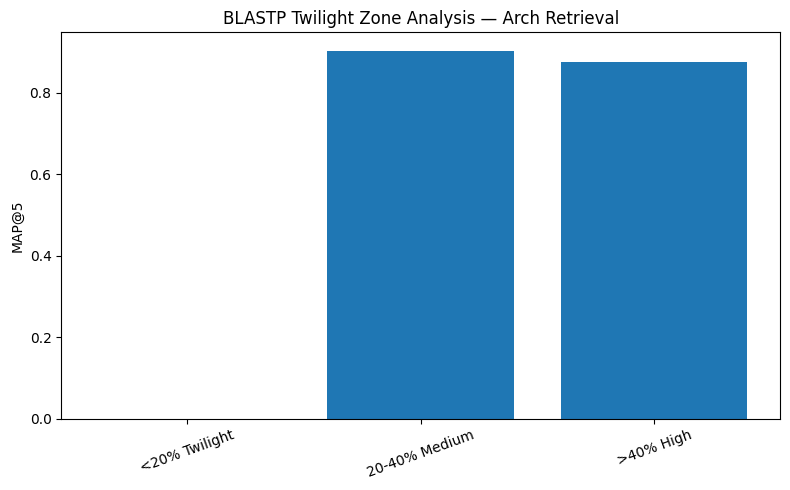

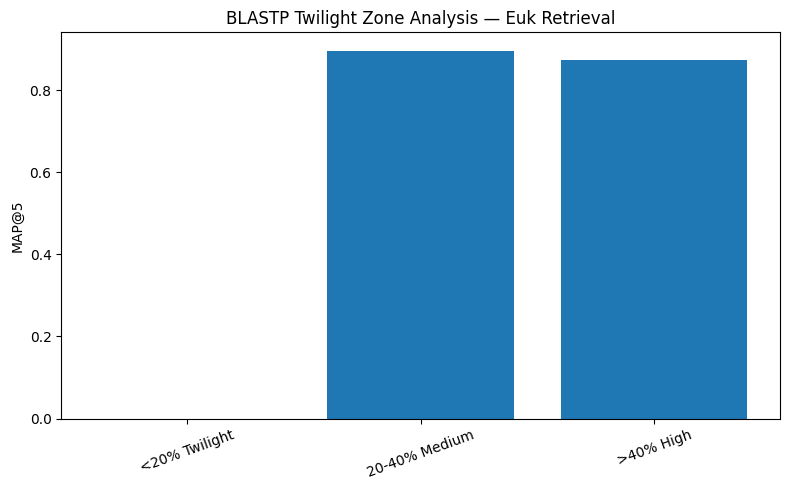

In [87]:
for task in ["Arch Retrieval", "Euk Retrieval"]:
    plot_df = blast_twilight_results[blast_twilight_results["Task"] == task]

    plt.figure(figsize=(8, 5))
    plt.bar(plot_df["Bin"], plot_df["MAP@5"])
    plt.ylabel("MAP@5")
    plt.title(f"BLASTP Twilight Zone Analysis — {task}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [88]:
blast_twilight_results.to_csv(
    f"{BLAST_DIR}/blast_twilight_results.csv",
    index=False
)

print("Saved:", f"{BLAST_DIR}/blast_twilight_results.csv")

Saved: /content/blast_method1/blast_twilight_results.csv


##part 2

In [89]:
from dgeb.tasks import ArchRetrieval, EukRetrieval
from collections import defaultdict

def load_dgeb_task(task_class, task_name):
    print(f"Loading {task_name} ...")

    task = task_class()
    meta = task.metadata

    data_ds = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()

    corpus = {row["Entry"]: row["Sequence"] for row in data_ds["train"]}
    queries = {row["Entry"]: row["Sequence"] for row in data_ds["test"]}

    qrels = defaultdict(set)

    splits = list(qrels_ds.values()) if hasattr(qrels_ds, "values") else [qrels_ds]

    for split in splits:
        for row in split:
            qid = str(row["query_id"])
            cid = str(row["corpus_id"])

            if float(row["fuzz_ratio"]) > 0:
                qrels[qid].add(cid)

    print(f"  Corpus  : {len(corpus):,}")
    print(f"  Queries : {len(queries):,}")
    print(f"  Queries with ≥1 relevant doc: {len(qrels):,}")
    print(f"  Query/qrel overlap: {len(set(queries.keys()) & set(qrels.keys())):,}")

    return queries, corpus, dict(qrels)

arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval, "Arch Retrieval")
euk_queries, euk_corpus, euk_qrels = load_dgeb_task(EukRetrieval, "Euk Retrieval")

Loading Arch Retrieval ...
  Corpus  : 9,229
  Queries : 2,343
  Queries with ≥1 relevant doc: 2,343
  Query/qrel overlap: 2,343
Loading Euk Retrieval ...
  Corpus  : 3,202
  Queries : 311
  Queries with ≥1 relevant doc: 311
  Query/qrel overlap: 311


In [90]:
import os
import pandas as pd
import numpy as np

BLAST_DIR = "/content/blast_method1"
os.makedirs(BLAST_DIR, exist_ok=True)

def write_fasta(seq_dict, output_path):
    with open(output_path, "w") as f:
        for protein_id, seq in seq_dict.items():
            seq = str(seq).replace("*", "").replace(" ", "").replace("\n", "")
            f.write(f">{protein_id}\n")
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + "\n")

arch_query_fasta = os.path.join(BLAST_DIR, "arch_queries.fasta")
arch_corpus_fasta = os.path.join(BLAST_DIR, "arch_bacterial_corpus.fasta")

euk_query_fasta = os.path.join(BLAST_DIR, "euk_queries.fasta")
euk_corpus_fasta = os.path.join(BLAST_DIR, "euk_bacterial_corpus.fasta")

write_fasta(arch_queries, arch_query_fasta)
write_fasta(arch_corpus, arch_corpus_fasta)

write_fasta(euk_queries, euk_query_fasta)
write_fasta(euk_corpus, euk_corpus_fasta)

print("FASTA files written.")

FASTA files written.


In [91]:
arch_db = os.path.join(BLAST_DIR, "arch_bacterial_db")
euk_db = os.path.join(BLAST_DIR, "euk_bacterial_db")

!makeblastdb -in {arch_corpus_fasta} -dbtype prot -out {arch_db}
!makeblastdb -in {euk_corpus_fasta} -dbtype prot -out {euk_db}



Building a new DB, current time: 05/05/2026 18:32:21
New DB name:   /content/blast_method1/arch_bacterial_db
New DB title:  /content/blast_method1/arch_bacterial_corpus.fasta
Sequence type: Protein
Deleted existing Protein BLAST database named /content/blast_method1/arch_bacterial_db
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 9229 sequences in 0.207879 seconds.




Building a new DB, current time: 05/05/2026 18:32:21
New DB name:   /content/blast_method1/euk_bacterial_db
New DB title:  /content/blast_method1/euk_bacterial_corpus.fasta
Sequence type: Protein
Deleted existing Protein BLAST database named /content/blast_method1/euk_bacterial_db
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 3202 sequences in 0.0758221 seconds.




In [92]:
arch_blast_tsv = os.path.join(BLAST_DIR, "blast_arch.tsv")
euk_blast_tsv = os.path.join(BLAST_DIR, "blast_euk.tsv")

outfmt = "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore"

In [93]:
!blastp \
-query {arch_query_fasta} \
-db {arch_db} \
-out {arch_blast_tsv} \
-outfmt "{outfmt}" \
-evalue 10 \
-max_target_seqs 100 \
-num_threads 2

print("Arch BLASTP complete.")

Arch BLASTP complete.


In [94]:
!blastp \
-query {euk_query_fasta} \
-db {euk_db} \
-out {euk_blast_tsv} \
-outfmt "{outfmt}" \
-evalue 10 \
-max_target_seqs 100 \
-num_threads 2

print("Euk BLASTP complete.")

Euk BLASTP complete.


In [95]:
BLAST_COLS = [
    "query_id", "corpus_id", "pident", "length", "mismatch", "gapopen",
    "qstart", "qend", "sstart", "send", "evalue", "bitscore"
]

def parse_blast(path, task_name):
    df = pd.read_csv(path, sep="\t", names=BLAST_COLS)
    df["task"] = task_name

    df = df.sort_values(
        ["query_id", "evalue", "bitscore"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return df

arch_blast_df = parse_blast(arch_blast_tsv, "arch")
euk_blast_df = parse_blast(euk_blast_tsv, "euk")

display(arch_blast_df.head())
display(euk_blast_df.head())

,query_id,corpus_id,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,task
0,A0A0S1X9S7,B1YI19,24.554,224,136,10,87,307,99,292,0.002,37.7,arch
1,A0A0S1X9S7,C5D3E0,20.500,200,128,4,10,201,15,191,0.018,35.0,arch
2,A0A0S1X9S7,Q8KCK9,23.977,171,104,6,128,284,117,275,0.061,33.1,arch
3,A0A0S1X9S7,A5N6A8,30.000,100,61,5,9,100,14,112,1.400,28.9,arch
4,A0A0S1X9S7,B0S101,30.120,83,36,3,297,378,660,721,1.600,28.9,arch


,query_id,corpus_id,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,task
0,A0A0B5L585,Q7UJL3,36.381,514,285,10,37,547,56,530,2.800000e-93,292.0,euk
1,A0A0B5L585,Q8G3N6,38.095,483,257,9,37,508,54,505,3.490000e-92,289.0,euk
2,A0A0B5L585,P49058,37.624,303,165,9,246,540,116,402,6.470000e-48,168.0,euk
3,A0A0B5L585,P49058,42.169,83,48,0,36,118,9,91,1.030000e-14,72.8,euk
4,A0A0B5L585,B9K819,20.769,130,80,3,274,382,18,145,2.900000e-01,30.0,euk


In [110]:
def blast_to_retrieved_list(blast_df, query_ids, max_k):
    topk = (
        blast_df
        .groupby("query_id")["corpus_id"]
        .apply(lambda x: list(dict.fromkeys(x))[:max_k])
        .to_dict()
    )

    return [topk.get(str(qid), []) for qid in query_ids]

arch_blast_retrieved = blast_to_retrieved_list(
    arch_blast_df,
    list(arch_queries.keys()),
    max_k=max(KS)
)

euk_blast_retrieved = blast_to_retrieved_list(
    euk_blast_df,
    list(euk_queries.keys()),
    max_k=max(KS)
)


In [97]:
def average_precision_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Compute Average Precision@k for a single query."""
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for rank, doc_id in enumerate(retrieved[:k], start=1):
        if doc_id in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Compute nDCG@k for a single query (binary relevance)."""
    if not relevant:
        return 0.0
    dcg = sum(
        (1.0 if doc_id in relevant else 0.0) / np.log2(rank + 1)
        for rank, doc_id in enumerate(retrieved[:k], start=1)
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def recall_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Compute Recall@k for a single query."""
    if not relevant:
        return 0.0
    hits = sum(1 for doc_id in retrieved[:k] if doc_id in relevant)
    return hits / len(relevant)


def evaluate_retrieval(
    query_ids: list,
    all_retrieved: list,
    qrels: dict,
    k: int = 5,
) -> dict:
    """Compute MAP@k, nDCG@k, Recall@k across all queries.

    Queries without any relevant document are excluded from the average
    (consistent with DGEB evaluation).
    """
    maps, ndcgs, recalls = [], [], []
    for qid, retrieved in zip(query_ids, all_retrieved):
        relevant = qrels.get(qid, set())
        if not relevant:
            continue
        maps.append(average_precision_at_k(retrieved, relevant, k))
        ndcgs.append(ndcg_at_k(retrieved, relevant, k))
        recalls.append(recall_at_k(retrieved, relevant, k))

    return {
        f'MAP@{k}':    float(np.mean(maps))    if maps else 0.0,
        f'nDCG@{k}':   float(np.mean(ndcgs))   if ndcgs else 0.0,
        f'Recall@{k}': float(np.mean(recalls)) if recalls else 0.0,
        'n_queries':   len(maps),
    }

In [98]:
!pip install pytrec_eval -q

In [99]:
import pytrec_eval
import pandas as pd
import numpy as np
import os

KS = [5, 10, 50]

def qrels_to_pytrec(qrels):
    return {
        str(qid): {str(cid): 1 for cid in rel_docs}
        for qid, rel_docs in qrels.items()
    }

def retrieved_list_to_run(query_ids, retrieved_list):
    run = {}

    for qid, docs in zip(query_ids, retrieved_list):
        qid = str(qid)
        run[qid] = {}

        # higher score = better rank
        for rank, doc_id in enumerate(docs):
            run[qid][str(doc_id)] = float(len(docs) - rank)

    return run

def evaluate_retrieval_pytrec_flexible(query_ids, retrieved_list, qrels, ks=[5, 10, 50]):
    pytrec_qrels = qrels_to_pytrec(qrels)
    pytrec_run = retrieved_list_to_run(query_ids, retrieved_list)

    metric_set = set()
    for k in ks:
        metric_set.update({
            f"map_cut.{k}",
            f"ndcg_cut.{k}",
            f"P.{k}",
            f"recall.{k}"
        })

    evaluator = pytrec_eval.RelevanceEvaluator(pytrec_qrels, metric_set)
    scores = evaluator.evaluate(pytrec_run)

    valid_qids = [str(qid) for qid in query_ids if str(qid) in pytrec_qrels]

    results = {}

    for k in ks:
        results[f"MAP@{k}"] = np.mean([scores[qid][f"map_cut_{k}"] for qid in valid_qids])
        results[f"nDCG@{k}"] = np.mean([scores[qid][f"ndcg_cut_{k}"] for qid in valid_qids])
        results[f"Precision@{k}"] = np.mean([scores[qid][f"P_{k}"] for qid in valid_qids])
        results[f"Recall@{k}"] = np.mean([scores[qid][f"recall_{k}"] for qid in valid_qids])

        # Manual MRR@k
        mrr_scores = []

        for i, qid in enumerate(query_ids):
            qid = str(qid)

            if qid not in pytrec_qrels:
                continue

            retrieved = retrieved_list[i]
            relevant_docs = set(pytrec_qrels[qid].keys())

            rr = 0.0

            for rank, doc_id in enumerate(retrieved[:k], start=1):
                if str(doc_id) in relevant_docs:
                    rr = 1.0 / rank
                    break

            mrr_scores.append(rr)

        results[f"MRR@{k}"] = np.mean(mrr_scores)

    results["n_queries"] = len(valid_qids)

    return results

In [100]:
def evaluate_retrieval_pytrec(query_ids, retrieved_list, qrels, k=5):
    pytrec_qrels = qrels_to_pytrec(qrels)
    pytrec_run = retrieved_list_to_run(query_ids, retrieved_list)

    evaluator = pytrec_eval.RelevanceEvaluator(
        pytrec_qrels,
        {f"map_cut.{k}", f"ndcg_cut.{k}", f"recall.{k}"}
    )

    scores = evaluator.evaluate(pytrec_run)

    valid_qids = [
        str(qid) for qid in query_ids
        if str(qid) in pytrec_qrels
    ]

    return {
        "MAP@5": np.mean([scores[qid][f"map_cut_{k}"] for qid in valid_qids]),
        "nDCG@5": np.mean([scores[qid][f"ndcg_cut_{k}"] for qid in valid_qids]),
        "Recall@5": np.mean([scores[qid][f"recall_{k}"] for qid in valid_qids]),
        "n_queries": len(valid_qids)
    }


blast_arch_metrics = evaluate_retrieval_pytrec_flexible(
    query_ids=list(arch_queries.keys()),
    retrieved_list=arch_blast_retrieved,
    qrels=arch_qrels,
    ks=KS
)

blast_euk_metrics = evaluate_retrieval_pytrec_flexible(
    query_ids=list(euk_queries.keys()),
    retrieved_list=euk_blast_retrieved,
    qrels=euk_qrels,
    ks=KS
)

df_blast_results_pytrec_flexible = pd.DataFrame([
    {
        "Method": "BLASTP",
        "Task": "Arch Retrieval",
        **blast_arch_metrics
    },
    {
        "Method": "BLASTP",
        "Task": "Euk Retrieval",
        **blast_euk_metrics
    }
])

display(df_blast_results_pytrec_flexible)

,Method,Task,MAP@5,nDCG@5,Precision@5,Recall@5,MRR@5,MAP@10,nDCG@10,Precision@10,Recall@10,MRR@10,MAP@50,nDCG@50,Precision@50,Recall@50,MRR@50,n_queries
0,BLASTP,Arch Retrieval,0.297843,0.901538,0.816304,0.304760,0.930161,0.414867,0.886198,0.742595,0.425707,0.930884,0.696271,0.820803,0.421997,0.717333,0.931174,2343
1,BLASTP,Euk Retrieval,0.337021,0.883795,0.801929,0.340058,0.916774,0.453243,0.866728,0.703537,0.459954,0.916774,0.668846,0.785894,0.341222,0.677644,0.916774,311


In [101]:
df_blast = pd.concat(
    [
        arch_blast_df[["task", "query_id", "corpus_id", "pident", "evalue", "bitscore"]],
        euk_blast_df[["task", "query_id", "corpus_id", "pident", "evalue", "bitscore"]]
    ],
    ignore_index=True
)

blast_pident_path = os.path.join("/content/blast_method1/", "blast_pident.csv")
df_blast.to_csv(blast_pident_path, index=False)

print("Saved:", blast_pident_path)
display(df_blast.head())

Saved: /content/blast_method1/blast_pident.csv


,task,query_id,corpus_id,pident,evalue,bitscore
0,arch,A0A0S1X9S7,B1YI19,24.554,0.002,37.7
1,arch,A0A0S1X9S7,C5D3E0,20.500,0.018,35.0
2,arch,A0A0S1X9S7,Q8KCK9,23.977,0.061,33.1
3,arch,A0A0S1X9S7,A5N6A8,30.000,1.400,28.9
4,arch,A0A0S1X9S7,B0S101,30.120,1.600,28.9


In [102]:
def bin_by_pident(pident: float) -> str:
    if pident >= 40:
        return ">40% (High)"
    if pident >= 20:
        return "20-40% (Medium)"
    return "<20% (Twilight)"


def twilight_zone_map(
    query_ids: list,
    retrieved_list: list,
    qrels: dict,
    df_blast_pident: pd.DataFrame,
    task_filter: str,
    k: int = 5,
) -> dict:
    task_blast = df_blast_pident[df_blast_pident["task"] == task_filter].copy()

    max_pident = (
        task_blast
        .groupby("query_id")["pident"]
        .max()
        .to_dict()
    )

    bin_aps = {
        ">40% (High)": [],
        "20-40% (Medium)": [],
        "<20% (Twilight)": []
    }

    for qid, retrieved in zip(query_ids, retrieved_list):
        qid = str(qid)
        relevant = qrels.get(qid, set())

        if not relevant:
            continue

        pident = max_pident.get(qid, 0.0)
        bin_label = bin_by_pident(pident)

        ap = average_precision_at_k(retrieved, relevant, k)
        bin_aps[bin_label].append(ap)

    return {
        bin_label: {
            "MAP@5": float(np.mean(aps)) if aps else np.nan,
            "n_queries": len(aps)
        }
        for bin_label, aps in bin_aps.items()
    }

In [103]:
TZ_RESULTS = []

def add_tz_rows(method, task_label, task_key, query_ids, retrieved_list, qrels):
    tz = twilight_zone_map(
        query_ids=query_ids,
        retrieved_list=retrieved_list,
        qrels=qrels,
        df_blast_pident=df_blast,
        task_filter=task_key,
        k=5
    )

    for bin_label, vals in tz.items():
        TZ_RESULTS.append({
            "Method": method,
            "Task": task_label,
            "Bin": bin_label,
            "MAP@5": vals["MAP@5"],
            "n_queries": vals["n_queries"]
        })


add_tz_rows(
    "BLASTP",
    "Arch Retrieval",
    "arch",
    list(arch_queries.keys()),
    arch_blast_retrieved,
    arch_qrels
)

add_tz_rows(
    "BLASTP",
    "Euk Retrieval",
    "euk",
    list(euk_queries.keys()),
    euk_blast_retrieved,
    euk_qrels
)

if "df_best" in globals() and "RETRIEVAL_RESULTS" in globals():
    for task_key, task_label, query_ids, qrels in [
        ("arch", "Arch Retrieval", TASK_CONFIG["arch"]["query_ids"], arch_qrels),
        ("euk", "Euk Retrieval", TASK_CONFIG["euk"]["query_ids"], euk_qrels)
    ]:
        for size in ["35M", "150M", "650M"]:
            row = df_best[
                (df_best["Method"] == f"ESM2-{size}") &
                (df_best["Task"] == task_label)
            ]

            if row.empty:
                continue

            best_layer = row.iloc[0]["Layer"]
            retrieved = RETRIEVAL_RESULTS[(size, best_layer, task_key)]

            add_tz_rows(
                f"ESM2-{size}",
                task_label,
                task_key,
                query_ids,
                retrieved,
                qrels
            )

df_twilight_comparison = pd.DataFrame(TZ_RESULTS)

display(
    df_twilight_comparison.sort_values(["Task", "Bin", "Method"])
)

df_twilight_comparison.to_csv(
    os.path.join("/content/blast_method1/", "twilight_comparison_blast_esm2.csv"),
    index=False
)

,Method,Task,Bin,MAP@5,n_queries
1,BLASTP,Arch Retrieval,20-40% (Medium),0.847069,290
2,BLASTP,Arch Retrieval,<20% (Twilight),NaN,0
0,BLASTP,Arch Retrieval,>40% (High),0.896226,2053
4,BLASTP,Euk Retrieval,20-40% (Medium),0.796212,44
5,BLASTP,Euk Retrieval,<20% (Twilight),NaN,0
3,BLASTP,Euk Retrieval,>40% (High),0.898608,267


In [114]:
df_blast_results_pytrec_flexible

,Method,Task,MAP@5,nDCG@5,Precision@5,Recall@5,MRR@5,MAP@10,nDCG@10,Precision@10,Recall@10,MRR@10,MAP@50,nDCG@50,Precision@50,Recall@50,MRR@50,n_queries
0,BLASTP,Arch Retrieval,0.297843,0.901538,0.816304,0.304760,0.930161,0.414867,0.886198,0.742595,0.425707,0.930884,0.696271,0.820803,0.421997,0.717333,0.931174,2343
1,BLASTP,Euk Retrieval,0.337021,0.883795,0.801929,0.340058,0.916774,0.453243,0.866728,0.703537,0.459954,0.916774,0.668846,0.785894,0.341222,0.677644,0.916774,311


In [106]:
blast_twilight_results.to_csv(
    os.path.join(CHECKPOINT_DIR, "blast_twilight_results.csv"),
    index=False
)

In [107]:
blast_twilight_results.to_csv(
    os.path.join(CHECKPOINT_DIR, "blast_twilight_results.csv"),
    index=False
)

In [115]:
df_blast_results_pytrec_flexible.to_csv(
    "/content/checkpoints/blast_retrieval_metrics_k5_k10_k50.csv",
    index=False
)